# Gợi ý Lọc cộng tác - Item-Based KNN dựa trên vector nhúng FastRP

## Introduction

Sử dụng Fast Random Projection để tạo các vector nhúng (embeddings) cho các nút Poi và User, sau đó dùng thuật toán K-Nearest Neighbors để tính toán độ tương đồng giữa các nút POI (Item).

Khi gợi ý, tìm các POI tương đồng nhất và gợi ý chúng cho người dùng mục tiêu dựa trên lịch sử ghé thăm của họ.

[Thuật toán K-Nearest Neighbors (kNN)](https://neo4j.com/docs/graph-data-science/current/algorithms/knn/): xác định các nút tương đồng và đưa ra gợi ý dựa trên đó.

[FastRP](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/fastrp/): tận dụng thông tin cấu trúc đồ thị trong kNN bằng cách tạo các vector nhúng nút trước.

## Điều kiện tiên quyết

Neo4j server đã được cài đặt phiên bản GDS mới (2.0+).

Thư viện Python `graphdatascience` để vận hành Neo4j GDS.

Truy vấn `Cypher` để tạo các gợi ý.

In [1]:
import os
import configparser

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from graphdatascience import GraphDataScience


d:\Thac_Si\De_an_thac_si\code\KG-Rec-Sys-Tourism-SG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Sử dụng file ini cho thông tin đăng nhập, nếu không sử dụng mặc định
HOST = 'neo4j://localhost'
DATABASE = 'neo4j'
PASSWORD = 'password'

NEO4J_CONF_FILE = 'neo4j.ini'

if NEO4J_CONF_FILE is not None and os.path.exists(NEO4J_CONF_FILE):
    config = configparser.RawConfigParser()
    config.read(NEO4J_CONF_FILE)
    HOST = config['NEO4J']['HOST']
    DATABASE = config['NEO4J'].get('DATABASE', 'neo4j')
    USERNAME = config['NEO4J'].get('USERNAME', DATABASE)
    PASSWORD = config['NEO4J']['PASSWORD']
    print(f'Using custom database properties \nHOST: {HOST}; DATABASE: {DATABASE}; PASSWORD: {PASSWORD}')
else:
    print('Could not find database properties file, using defaults')

# Kết nối với cơ sở dữ liệu Neo4j bằng thư viện GDS
gds = GraphDataScience(HOST, auth=(USERNAME, PASSWORD))
gds.set_database(DATABASE)

Using custom database properties 
HOST: neo4j://127.0.0.1:7687; DATABASE: neo4j; PASSWORD: 12345678


## Chiếu (Projecting) đồ thị vào GDS

Chiếu đồ thị vào bộ nhớ (in-memory) để GDS có thể thao tác và phân tích dữ liệu

In [5]:
# Khi chạy lại, xóa đồ thị đã tạo trước đó nếu cần
#gds.graph.drop('myGraph')

graphName                                                          myGraph
database                                                             neo4j
databaseLocation                                                     local
memoryUsage                                                               
sizeInBytes                                                             -1
nodeCount                                                            58725
relationshipCount                                                   170068
configuration            {'relationshipProjection': {'REVIEWED': {'aggr...
density                                                           0.000049
creationTime                           2024-03-09T06:42:49.115688170+00:00
modificationTime                       2024-03-09T06:57:49.962132173+00:00
schema                   {'graphProperties': {}, 'nodes': {'User': {'em...
schemaWithOrientation    {'graphProperties': {}, 'nodes': {'User': {'em...
Name: 0, dtype: object

In [3]:
# định nghĩa cách chiếu cơ sở dữ liệu vào GDS
node_projection = ["User", "Poi"]
relationship_projection = {"REVIEWED": {"orientation": "UNDIRECTED", "properties": "rating"}}

# Trước khi chiếu thực tế, ước lượng lượng bộ nhớ cần thiết
result = gds.graph.project.estimate(node_projection, relationship_projection)

print(f"Required memory for native loading: {result['requiredMemory']}")

Required memory for native loading: [5515 KiB ... 5707 KiB]


In [4]:
# Kiểm tra và xóa đồ thị 'myGraph' đã tồn tại trong bộ nhớ trước khi chiếu
if gds.graph.exists("myGraph")["exists"]:
    gds.graph.drop(gds.graph.get("myGraph"))

# tiến hành chiếu đồ thị
G, result = gds.graph.project("myGraph", node_projection, relationship_projection)

print(f"The projection took {result['projectMillis']} ms")

# các phương thức trên `G` để kiểm tra xem đồ thị được chiếu có đúng không
print(f"Graph '{G.name()}' node count: {G.node_count()}")
print(f"Graph '{G.name()}' node labels: {G.node_labels()}")

The projection took 9152 ms
Graph 'myGraph' node count: 24641
Graph 'myGraph' node labels: ['User', 'Poi']


## Tạo các vector nhúng nút bằng FastRP

Để thực hiện lọc cộng tác, tạo các vector nhúng nút nắm bắt thông tin cấu trúc từ đồ thị, làm đầu vào cho KNN sau này.

`embeddingDimension` được thiết lập là 256 cho đồ thị có hơn 24k nút. 

Chạy chế độ mutate của FastRP để ghi thuộc tính nhúng trực tiếp vào đồ thị được chiếu.

[phần cú pháp của tài liệu FastRP](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/fastrp/#algorithms-fastrp-syntax) 

In [5]:
# ước lượng bộ nhớ khi chạy các thuật toán như FastRP
result = gds.fastRP.mutate.estimate(
    G,
    randomSeed=42,
    embeddingDimension=256,
    relationshipWeightProperty="rating",
    iterationWeights=[0, 1, 1, 1],
    mutateProperty="embedding"
)

print(f"Dung lượng bộ nhớ cần thiết để chạy FastRP: {result['requiredMemory']}")

Dung lượng bộ nhớ cần thiết để chạy FastRP: 74 MiB


In [6]:
# chạy FastRP và đột biến (mutate) đồ thị được chiếu của chúng ta với kết quả
result = gds.fastRP.mutate(
    G,
    randomSeed=42,
    embeddingDimension=256,
    relationshipWeightProperty="rating",
    iterationWeights=[0, 1, 1, 1],
    mutateProperty="embedding"
)


print(f"Số lượng embedding vectors được tạo ra: {result['nodePropertiesWritten']}")

Số lượng embedding vectors được tạo ra: 24641


## Similarities with ItemkNN

Xác định các nút tương đồng bằng cách sử dụng các vector nhúng nút được tạo bởi FastRP làm thuộc tính `nodeProperties`. 

Sử dụng chế độ write của thuật toán để ghi ngược các thuộc tính và quan hệ vào cơ sở dữ liệu, phân tích chúng sau bằng Cypher.

[phần cú pháp của tài liệu KNN](https://neo4j.com/docs/graph-data-science/current/algorithms/knn/#algorithms-knn-syntax) 

In [7]:
def topK_tuning():
    
    top_k_list = []

    for k in range(1,30):
        result = gds.knn.write(
        G,
        topK=k,
        nodeLabels=['Poi'],
        nodeProperties=["embedding"],
        randomSeed=42,
        concurrency=1,
        sampleRate=1.0,
        deltaThreshold=0.0,
        similarityCutoff = 0.5,
        writeRelationshipType="CF_SIMILAR_POI_"+str(k),
        writeProperty="score",

        )
        print(f"topK = {k}")
        print(f"Relationships produced: {result['relationshipsWritten']}")
        print(f"Nodes compared: {result['nodesCompared']}")
        print(f"Mean similarity: {result['similarityDistribution']['mean']}")

        top_k_list.append([k, result['similarityDistribution']['mean']])
    
    return top_k_list

In [8]:
top_k_list = topK_tuning() 

# thời gian chạy của hàm này sẽ mất khoảng 30s,
# Của tác giả
#top_k_list = [[1, 0.5615123804064764], [2, 0.5623639701069265], [3, 0.5574946380467807], [4, 0.554076719975126], [5, 0.5512441994487376], [6, 0.5485879465001793], [7, 0.546071125607066], [8, 0.5438574500705885], [9, 0.5419597656446571], [10, 0.5401918273041214], [11, 0.5385650363364238], [12, 0.5370458427834626], [13, 0.5355762111702093], [14, 0.5341640101209684], [15, 0.5327862467742772], [16, 0.5314491520757261], [17, 0.5301647722873541], [18, 0.5289336863347298], [19, 0.5277449144469609], [20, 0.5265708840411643], [21, 0.5254155824396675], [22, 0.524274883848248], [23, 0.5231545141228505], [24, 0.522049569853262], [25, 0.5209552411065586], [26, 0.5198528657655918], [27, 0.5187570773588991], [28, 0.5176656172142265], [29, 0.5165905988198528]]

# Của tôi
# Thực nghiệm lần 1: embeddingDimension = 256 chiều
# top_k_list = [[1, 0.6190855620778329], [2, 0.6145298665938491], [3, 0.6084732563214287], [4, 0.6047044600687175], [5, 0.6013997012032104], [6, 0.5993003540326016], [7, 0.5971177631680245], [8, 0.5953910054878052], [9, 0.5938952379775185], [10, 0.5926547205162317], [11, 0.591503393009605], [12, 0.5904506130514428], [13, 0.5892478344406057], [14, 0.5884927904896503], [15, 0.5876400592913357], [16, 0.5867457124174734], [17, 0.5860778016093795], [18, 0.58528001920087], [19, 0.584638319198861], [20, 0.5839655841187126], [21, 0.5833583059060469], [22, 0.582778595001029], [23, 0.5821900245215955], [24, 0.5816413756542269], [25, 0.5810330590811704], [26, 0.580515944907292], [27, 0.5800470300262042], [28, 0.5794829780383381], [29, 0.5790616805367558]]

# Thực nghiệm lần 2: embeddingDimension = 128 chiều
# top_k_list = [[1, 0.6548213931838279], [2, 0.649218315802441], [3, 0.6423696411233246], [4, 0.6390215580486949], [5, 0.6353814952296162], [6, 0.633204644422437], [7, 0.630933232396787], [8, 0.6289812597132199], [9, 0.6275683828813308], [10, 0.6259615337226556], [11, 0.6247922863344578], [12, 0.623512776513362], [13, 0.6222450274558211], [14, 0.6212661665532706], [15, 0.620071620430025], [16, 0.6191971954404888], [17, 0.6182478184147335], [18, 0.6173416401334475], [19, 0.6160058954689287], [20, 0.6154296279121689], [21, 0.6147460554467398], [22, 0.6138375313224846], [23, 0.6131445739141619], [24, 0.6123625028284716], [25, 0.6116933782278903], [26, 0.6110620913568153], [27, 0.6104532686301373], [28, 0.6098373973415235], [29, 0.6092222452244866]]

# Thực nghiệm lần 3: embeddingDimension = 128 chiều (Bộ dữ liệu crawl lại)
# top_k_list = [[1, 0.6515173015309803], [2, 0.6438458485389823], [3, 0.6386865758184177], [4, 0.6344181672850652], [5, 0.6320564383891092], [6, 0.6302398648428087], [7, 0.6282881441909367], [8, 0.6268263307969961], [9, 0.6253107371417247], [10, 0.6240627564956893], [11, 0.6229037060989939], [12, 0.6217585793775112], [13, 0.6206597920537131], [14, 0.6195601381981043], [15, 0.6185955554335865], [16, 0.6177088780189628], [17, 0.6167543158393036], [18, 0.6158691996167943], [19, 0.6150706281459716], [20, 0.61406864365535], [21, 0.6132136271028715], [22, 0.6125822219952153], [23, 0.611977660385221], [24, 0.6111770763919128], [25, 0.6103422620403233], [26, 0.6097963549923815], [27, 0.6091767661672985], [28, 0.6085510607721455], [29, 0.6079515497401027]]

# Thực nghiệm lần 4: embeddingDimension = 256 chiều (Bộ dữ liệu crawl lại)
# top_k_list = [[1, 0.6156053457687151], [2, 0.6091097418941669], [3, 0.6060828640686339], [4, 0.6021495050458766], [5, 0.6006477276246939], [6, 0.598370098474607], [7, 0.5965705932584653], [8, 0.5950835459267915], [9, 0.5936192865197734], [10, 0.592270576420115], [11, 0.5913734870817476], [12, 0.5903177524680522], [13, 0.5894364005525679], [14, 0.5884498819867685], [15, 0.587731481903228], [16, 0.5869334026948729], [17, 0.5862023411349732], [18, 0.585444633363689], [19, 0.5848099593936413], [20, 0.5839825869318265], [21, 0.583524565571322], [22, 0.5829529599224696], [23, 0.5823618659255259], [24, 0.5817853160165436], [25, 0.5811542143181189], [26, 0.5804905720611117], [27, 0.5801375351669118], [28, 0.5796570087546733], [29, 0.5791793621022003]]
print(top_k_list)

 Knn: 100%|██████████| 100.0/100 [00:00<00:00, 135.79%/s, status: FINISHED]                                


topK = 1
Relationships produced: 1340
Nodes compared: 3326
Mean similarity: 0.6156053457687151


 Knn: 100%|██████████| 100.0/100 [00:00<00:00, 126.06%/s, status: FINISHED]                                


topK = 2
Relationships produced: 2680
Nodes compared: 3326
Mean similarity: 0.6091097418941669


 Knn: 100%|██████████| 100.0/100 [00:00<00:00, 107.17%/s, status: FINISHED]                                


...

topK = 27
Relationships produced: 36180
Nodes compared: 3326
Mean similarity: 0.5801375351669118


 Knn: 100%|██████████| 100.0/100 [00:02<00:00, 42.79%/s, status: FINISHED]                                


topK = 28
Relationships produced: 37520
Nodes compared: 3326
Mean similarity: 0.5796570087546733


 Knn: 100%|██████████| 100.0/100 [00:02<00:00, 43.74%/s, status: FINISHED]                                

topK = 29
Relationships produced: 38860
Nodes compared: 3326
Mean similarity: 0.5791793621022003
[[1, 0.6156053457687151], [2, 0.6091097418941669], [3, 0.6060828640686339], [4, 0.6021495050458766], [5, 0.6006477276246939], [6, 0.598370098474607], [7, 0.5965705932584653], [8, 0.5950835459267915], [9, 0.5936192865197734], [10, 0.592270576420115], [11, 0.5913734870817476], [12, 0.5903177524680522], [13, 0.5894364005525679], [14, 0.5884498819867685], [15, 0.587731481903228], [16, 0.5869334026948729], [17, 0.5862023411349732], [18, 0.585444633363689], [19, 0.5848099593936413], [20, 0.5839825869318265], [21, 0.583524565571322], [22, 0.5829529599224696], [23, 0.5823618659255259], [24, 0.5817853160165436], [25, 0.5811542143181189], [26, 0.5804905720611117], [27, 0.5801375351669118], [28, 0.5796570087546733], [29, 0.5791793621022003]]


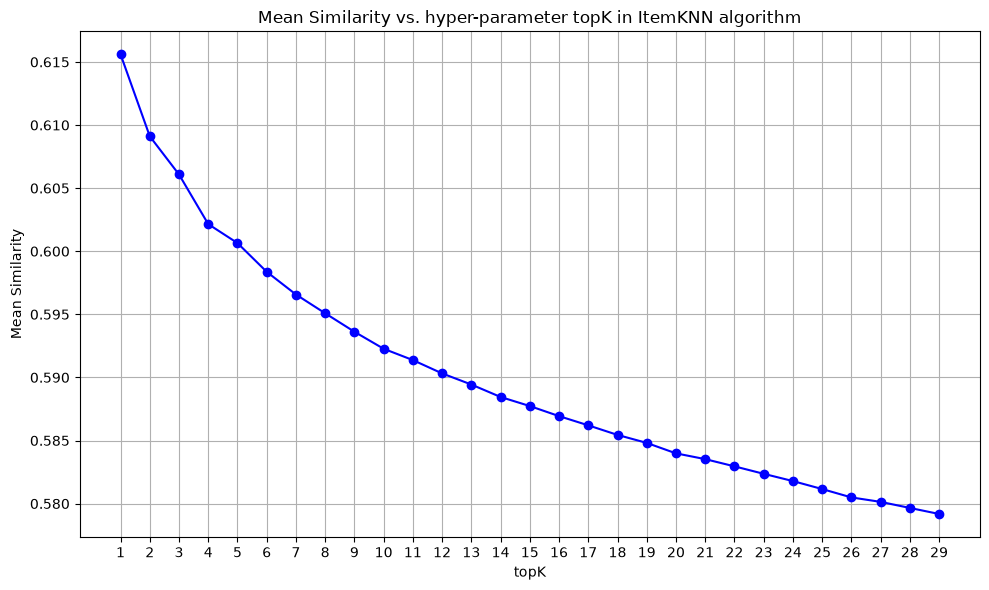

In [9]:
# trực quan hóa xu hướng Mean Similarity so với topK

# Chuyển đổi danh sách thành DataFrame
df_topK = pd.DataFrame(top_k_list, columns=['topK', 'mean_similarity'])

# Vẽ biểu đồ đường
plt.figure(figsize=(10, 6))
plt.plot(df_topK['topK'], df_topK['mean_similarity'], marker='o', color='b', linestyle='-')
plt.title('Mean Similarity vs. hyper-parameter topK in ItemKNN algorithm')
plt.xlabel('topK')
plt.ylabel('Mean Similarity')
plt.grid(True)
plt.xticks(df_topK['topK'])
plt.tight_layout()
plt.show()

In [10]:
# tìm topK tốt nhất

# Tìm chỉ mục của dòng có mean_similarity lớn nhất
max_index = df_topK['mean_similarity'].idxmax()

# Lấy giá trị topK tương ứng với mean_similarity lớn nhất
topK_best = df_topK.loc[max_index, 'topK']

print("TopK value corresponding to the maximum mean_similarity:", topK_best)


TopK value corresponding to the maximum mean_similarity: 1


In [11]:
# Tính tương đồng với Item-based KNN

# Chạy KNN với siêu tham số topK tối ưu và ghi ngược lại DB

topK_best = 1

result = gds.knn.write(
    G,
    topK=topK_best,
    nodeLabels = ['Poi'],
    nodeProperties=["embedding"],
    randomSeed=42,
    concurrency=1,
    sampleRate=1.0,
    deltaThreshold=0.0,
    similarityCutoff = 0.5,
    writeRelationshipType="CF_SIMILAR_POI",
    writeProperty="score"
)

print(f"Relationships produced: {result['relationshipsWritten']}")
print(f"Nodes compared: {result['nodesCompared']}")
print(f"Mean similarity: {result['similarityDistribution']['mean']}")

 Knn: 100%|██████████| 100.0/100 [00:00<00:00, 126.38%/s, status: FINISHED]                                

Relationships produced: 1340
Nodes compared: 3326
Mean similarity: 0.6156053457687151


## Khám phá kết quả

Kiểm tra kết quả gọi kNN bằng cách sử dụng Cypher. 

Sử dụng kiểu quan hệ `SIMILARITY` để lọc ra các mối quan hệ.

In [12]:
# tìm độ tương đồng lớn nhất giữa các cặp
gds.run_cypher(
    """
        MATCH (p1:Poi)-[r:CF_SIMILAR_POI]->(p2:Poi)
        RETURN p1.name AS poi1, p2.name AS poi2, r.score AS similarity
        ORDER BY similarity DESC, poi1, poi2
        LIMIT 10
    """
)

,poi1,poi2,similarity
0,B/S Art Studio,XQ Art House,1.000000
1,Jojo Spa Barbershop Nail,Vip Barbershop,1.000000
2,Vip Barbershop,Jojo Spa Barbershop Nail,1.000000
3,XQ Art House,B/S Art Studio,1.000000
4,Candi Shop,Xing Xing Nightclub,0.999550
5,Xing Xing Nightclub,Candi Shop,0.999550
6,Rue Miche Boutique,Rue Miche L'édition,0.977455
7,Rue Miche L'édition,Rue Miche Boutique,0.977455
8,Genki Spa,Genki Spa 1,0.961202
9,Genki Spa 1,Genki Spa,0.961202


In [13]:
# tìm độ tương đồng nhỏ nhất giữa các người dùng
gds.run_cypher(
    """
        MATCH (p1:Poi)-[r:CF_SIMILAR_POI]->(p2:Poi)
        RETURN p1.name AS poi1, p2.name AS poi2, r.score AS similarity
        ORDER BY similarity ASC, poi1, poi2
        LIMIT 10
    """
)

,poi1,poi2,similarity
0,V Galaxy Spa,Lotus Travel,0.561703
1,SaigonSniper,The Libra House,0.564508
2,Elegant Travel,Taka Plaza,0.567610
3,Anupa Ecoluxe Boutique,T&Q spa,0.568846
4,22Nail,Ho Chi Minh City Private Transfers & Limo Serv...,0.569353
5,Saigon Private Car Limousine,Colours of Vietnam,0.569493
6,Kim Spa,NP CLINIC – Nâng mũi – Cắt mí – Treo cung mày ...,0.570032
7,Lucy Henna,K Beauty Spa,0.570325
8,DC Saigontours,Mr Biker Saigon,0.570717
9,SARTOLAD Tailor - Bespoke & Suit,Cong Vien 23 Thang 9,0.571037


## Tiến hành gợi ý

Tạo gợi ý POI cho người dùng từ các người dùng tương đồng khác bằng truy vấn Cypher đơn giản.

In [14]:
# HÀM: Tạo gợi ý dựa trên Lọc cộng tác - Item-Based KNN dựa trên vector nhúng FastRP
# INPUT: poi_id
# OUTPUT: dataframe[poi_id, rec_poi_id]

def itemKNN_recommendation(poi_id):
    result = gds.run_cypher(
        """
            MATCH (p1:Poi {id: $target_poi})-[s:CF_SIMILAR_POI]->(p2:Poi)
            RETURN p1.id as poi_id, p2.id as rec_poi_id
            ORDER BY s.score DESC, p2.avgRating DESC
        """, params = {'target_poi': poi_id}
    )
    result = result.drop_duplicates()
    return result

In [15]:
# ID của POI mục tiêu
poi_id = 317890

itemKNN_recommendation(poi_id)

,poi_id,rec_poi_id
0,317890,33316308


# Đánh giá

In [16]:
# DataFrame các POI
df_pois = gds.run_cypher("""\
    MATCH (poi:Poi)    
    RETURN poi.id
    """)

df_pois

,poi.id
0,311103
1,2005826
2,311087
3,4542125
4,311089
...,...
3321,34509929
3322,34508995
3323,34515006
3324,34435391


In [17]:
# DataFrame các đánh giá

df_reviews = gds.run_cypher("""\
    MATCH (user:User)-[review:REVIEWED]->(poi:Poi)
    RETURN user.id AS user_id, poi.id AS poi_id
    """)

df_reviews

,user_id,poi_id
0,1,311103
1,2,311103
2,3,311103
3,4,311103
4,5,311103
...,...,...
23943,21311,15129760
23944,21312,15129760
23945,21313,15129760
23946,21314,15129760


In [18]:
# Nhóm theo 'user_id' và đếm số lần xuất hiện
user_counts = df_reviews.groupby('user_id').size()

# Lọc ra các người dùng có ít hơn 5 lần xuất hiện
valid_users = user_counts[user_counts >= 5].index

# Lọc DataFrame gốc dựa trên danh sách người dùng hợp lệ
filtered_df_reviews = df_reviews[df_reviews['user_id'].isin(valid_users)].copy()
filtered_df_reviews

,user_id,poi_id
50,51,311103
51,52,311103
103,104,311103
116,117,311103
118,119,311103
...,...,...
23570,481,12829864
23571,1303,12829864
23573,2886,12829864
23613,1246,9974597


In [19]:
# Chia tập dữ liệu thành 90% tập huấn luyện (training) và 10% tập kiểm tra (test)
df_train, df_test = train_test_split(filtered_df_reviews, test_size=0.1, random_state=100)

df_train

,user_id,poi_id
23463,181,9806390
2694,473,311094
3279,1177,1910195
2331,1334,10836601
8110,51,16657089
...,...,...
4403,284,311092
555,493,4542125
2215,1459,4552853
745,52,2037764


In [20]:
df_test

,user_id,poi_id
3284,1253,1910195
5049,683,552637
14873,606,10044301
1854,472,317896
2336,1415,10836601
...,...,...
1378,1006,10005057
23298,181,10388517
23338,474,1809055
545,484,311087


In [21]:
# Lấy gợi ý cho từng dòng trong tập kiểm tra

df_all_retrieved = pd.DataFrame()
for index, row in df_test.iterrows():
    poi_id = row['poi_id']

    recommended_interactions = itemKNN_recommendation(poi_id)

    # Nối các tương tác gợi ý với test_recommendations
    df_all_retrieved = pd.concat([df_all_retrieved, recommended_interactions], ignore_index=True)

# Drop the duplicated column
df_all_retrieved = df_all_retrieved.drop_duplicates()

df_all_retrieved

,poi_id,rec_poi_id
0,1910195,2407915
1,552637,8295665
2,10044301,28010412
3,317896,16657089
4,10836601,33316308
...,...,...
95,9996374,7927054
97,1784754,8295665
98,2414430,16657089
100,10388517,6403614


In [22]:
# Trích xuất các tương tác thực tế của tất cả các cặp POI được đánh giá bởi cùng người dùng

# Nhóm theo user_id và tổng hợp các poi_id thành một danh sách
grouped = df_reviews.groupby('user_id')['poi_id'].apply(list)

# Khởi tạo một DataFrame trống cho kết quả
df_true_interactions = pd.DataFrame(columns=['poi_id', 'rec_poi_id'])

# Lặp qua từng nhóm
for user_id, poi_ids in grouped.items():
    # Tạo các cặp target_poi_id và poi_id cho từng người dùng
    pairs = [(poi_id, other_poi_id) for poi_id in poi_ids for other_poi_id in poi_ids if poi_id != other_poi_id]
    df_pairs = pd.DataFrame(pairs, columns=['poi_id', 'rec_poi_id'])
    # Thêm các cặp vào DataFrame kết quả
    df_true_interactions = pd.concat([df_true_interactions, df_pairs], ignore_index=True)

df_true_interactions = df_true_interactions.drop_duplicates()
# Hiển thị DataFrame kết quả
df_true_interactions

,poi_id,rec_poi_id
0,311103,2005826
1,311103,311087
2,311103,8587831
3,2005826,311103
4,2005826,311087
...,...,...
19089,11435998,10813505
19090,2493165,17376382
19091,17376382,2493165
19092,13613302,10836471


In [23]:
# Lấy tất cả các thực thể liên quan bằng cách gộp các tương tác thực tế và thực thể kiểm tra
df_all_relevant = pd.merge(df_true_interactions, df_test, on=['poi_id'], how='inner')
# Loại bỏ cột user_id
df_all_relevant = df_all_relevant.drop(columns=['user_id'])
# kiểm tra cặp POI không phải là cùng một POI
df_all_relevant = df_all_relevant[df_all_relevant['poi_id'] != df_all_relevant['rec_poi_id']]
# Loại bỏ trùng lặp
df_all_relevant = df_all_relevant.drop_duplicates()

df_all_relevant

,poi_id,rec_poi_id
0,2005826,311103
2,2005826,311087
4,2005826,8587831
6,311087,311103
10,311087,2005826
...,...,...
10116,10044301,13873247
10117,13447187,34239306
10118,13447187,13961526
10119,1949590,16698454


In [24]:
# Lấy tất cả các thực thể gợi ý liên quan bằng cách gộp tương tác thực tế và tương tác gợi ý
df_retrived_relevant = pd.merge(df_all_retrieved, df_all_relevant, on=['poi_id', 'rec_poi_id'], how='inner')

df_retrived_relevant

,poi_id,rec_poi_id
0,1910195,2407915
1,552637,8295665
2,317896,16657089
3,10836601,33316308
4,317898,1809055
5,10085046,4498781
6,5505885,2273343
7,311092,7916284
8,8310942,19041755
9,1929610,311105


In [25]:
# Tính chỉ số độ chính xác (precision score)
relevant_retrieved = df_retrived_relevant.shape[0]
all_retrived = df_all_retrieved.shape[0]

precision = relevant_retrieved / all_retrived

print(f'Precision Score: {precision}')

Precision Score: 0.8360655737704918


In [26]:
# Tính chỉ số độ bao phủ (recall score)
relevant_retrieved = df_retrived_relevant.shape[0]
all_relevant = df_all_relevant.shape[0]

recall = relevant_retrieved / all_relevant
print(f'Recall Score: {recall}')

Recall Score: 0.01054372544965888


In [27]:
# Tính chỉ số độ phủ (coverage score)
num_recommended_pois = df_all_retrieved['rec_poi_id'].nunique()
num_all_pois = df_pois.shape[0]

coverage = num_recommended_pois / num_all_pois
print(f'Coverage Score: {coverage}')

Coverage Score: 0.01413108839446783


In [28]:
# Tính điểm F1 (F1 score)
f1 = (2 * precision * recall) / (precision + recall)
print(f'F1 Score: {f1}')

F1 Score: 0.020824826459779504


## Dọn dẹp tài nguyên

Xóa đồ thị GDS in-memory.

In [6]:
# Xóa đồ thị chiếu của chúng ta khỏi danh mục GDS
G.drop()

# Xóa tất cả dữ liệu ví dụ khỏi cơ sở dữ liệu
# _ = gds.run_cypher("MATCH (n) DETACH DELETE n")

graphName                                                          myGraph
database                                                             neo4j
databaseLocation                                                     local
memoryUsage                                                               
sizeInBytes                                                             -1
nodeCount                                                            24641
relationshipCount                                                    47896
configuration            {'relationshipProjection': {'REVIEWED': {'orie...
density                                                           0.000079
creationTime                           2026-07-21T12:47:15.466994700+07:00
modificationTime                       2026-07-21T12:47:15.466994700+07:00
schema                   {'relationships': {'REVIEWED': {'rating': 'Flo...
schemaWithOrientation    {'relationships': {'REVIEWED': {'properties': ...
Name: 0, dtype: object